# PlantCV + Napari + Segment Anything Tutorial

In [ ]:
# Install PlantCV and required dependencies
%pip install "altair>=5" plantcv

# Give access and mount your Google Drive (need a Google Account)
# Change path to directory you wish output files to be saved to.
from google.colab import drive
drive.mount('/content/gdrive')

# Enable widget feature with matplotlib
from google.colab import output
output.enable_custom_widget_manager()

#View working directory, may need to change path
%pwd

## Section 0: Import libraries and define local functions

In [1]:
%gui qt

import os
from plantcv import plantcv as pcv
from plantcv.parallel import WorkflowInputs
import napari
import plantcv.annotate as pcvan
import cv2
import numpy as np
from datetime import datetime

In [2]:
pcv.__version__

'4.10.2.dev173+gf13ad8a6a'

In [3]:
# Input/output options
args = WorkflowInputs(
    images=["./img/CoVar_0300_1.png"],
    names="image",
    result="example_output.csv",
    outdir=".",
    writeimg=False,
    debug="plot"
    )

In [4]:
# Set debug to the global parameter 
pcv.params.debug = args.debug
# Change display settings
pcv.params.dpi = 140
pcv.params.text_size = 10

# Google Colaboratory Users:

## If you are running this notebook using Google Colaboratory, you will need to use the cell below to complete the tutorial unless you cloned the repository from GitHub to your personal Google Drive account. Once you begin developing your workflow for your data, you can delete this text cell and the code cell below so you avoid any conflicts the next time you use this notebook.

In [ ]:
img = pcv.io.open_url(url="https://raw.githubusercontent.com/danforthcenter/plantcv-tutorial-template/main/img/CoVar_0300_1.png")

# Local system use:
## If you have downloaded this notebook or the repository to your local device, then you will need to use the cell below to bring your image into the notebook. Do not run this line if you are navigating through the tutorial using Google Colaboratory.

## NOTE: If you are developing your own workflow using this notebook, make sure you remove the code cell above with the URL and uncomment (remove the hashtag [#] to make the code active. This will call the image you defined during the Inputs/Outputs step.

### Reading images into your environment using *pcv.readimage()*
Inputs:
   * filename = Image file to be read in
   * mode     = How the image will be read into the notebook; either 'native' (default), 'rgb', 'gray', 'csv', or 'envi'

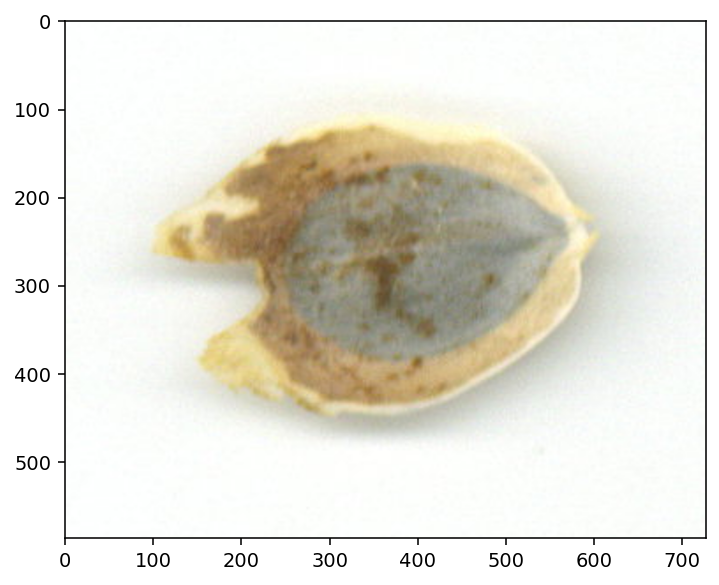

In [5]:
img, path, name = pcv.readimage(args.image)

# Napari to pick points

## The following steps would be interactive if done locally. 

## The goal for this image is to segment the inner seed but not the seed wing. 

![overlay img](./img/pos-neg-points.png)

In [6]:
#viewer = pcvan.napari_label_classes(img, classes=['pos','neg'], size=5,
#                         importdata=False, show=True)

In [7]:
#points = pcvan.napari_save_coor(viewer, "./points.txt")

In [8]:
# For the purposes here, load pre-picked points
points1 = pcvan.napari_read_coor("./points.txt",dataformat="sam")

#if points had been picked interactively you'd still need to convert them to 'sam' format 
#points1 = pcvan.napari_read_coor(points,dataformat="sam")

In [10]:
print(points1)
print(points1['points'])
print(points1['labels'])

{'pos': [(296, 250), (331, 239)], 'neg': [(203, 376)], 'points': [[[296, 250], [331, 239], [203, 376]]], 'labels': [[1, 1, 0]]}
[[[296, 250], [331, 239], [203, 376]]]
[[1, 1, 0]]


# Using Segment Anything 

## The following codeblock uses the ultralytics package with the Sam3 model downloaded via Hugging Face to segment the image with the positive and negative points picked above. To segment multiple objects use the bounding box method (Tutorial Link) or Segment Anything 3 with Concepts (Tutorial Link) 

In [11]:
#from ultralytics import SAM
#from ultralytics.models.sam import SAM3SemanticPredictor
#import torch
#print(f"MPS available: {torch.backends.mps.is_available()}")
#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
#print(f"Using device: {device}")

#model = SAM("sam3.pt")

#tmp_img_path = "./tmp_sam_input.png"
#cv2.imwrite(tmp_img_path, img)

##Multiple points - segments single object with multiple point hints
#results = model.predict(source = tmp_img_path, points= points1['points'], labels = points1['labels'])


In [12]:
#import pickle
#with open("results.pkl", "wb") as f:
#    pickle.dump(results, f)

In [13]:
import pickle

with open("results.pkl", "rb") as f:
    results = pickle.load(f)

/Users/mgehan/Documents/github/plantcv/build/__editable__.plantcv-4.10.2.dev173+gf13ad8a6a-py3-none-any/plantcv/plantcv/_helpers.py:899: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  return function(sub_img, **kwargs)


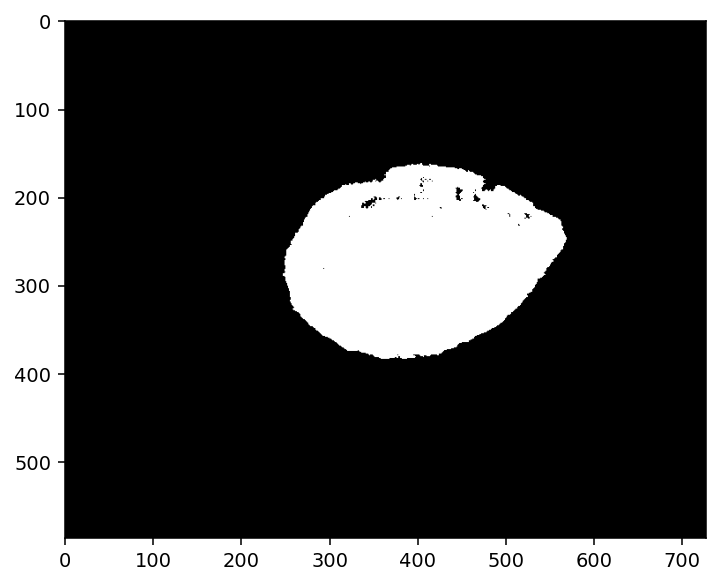

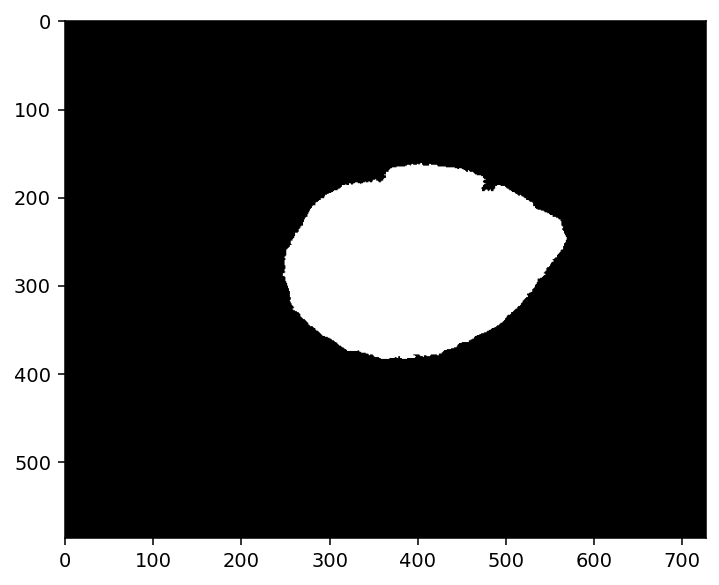

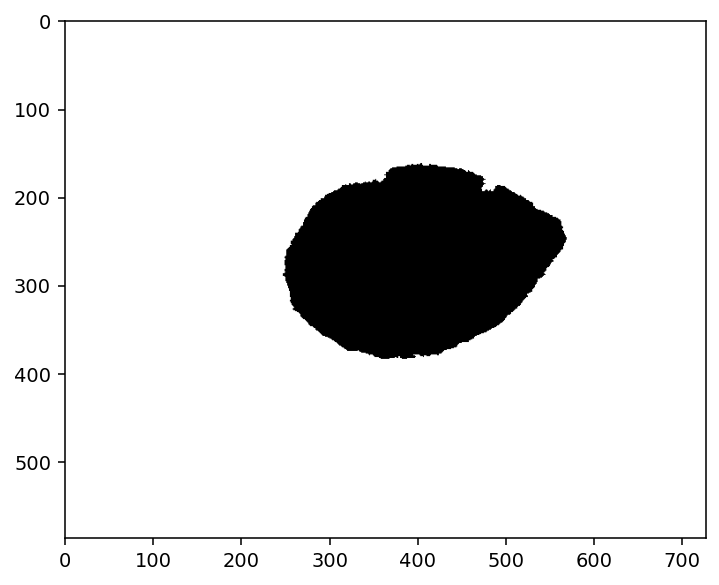

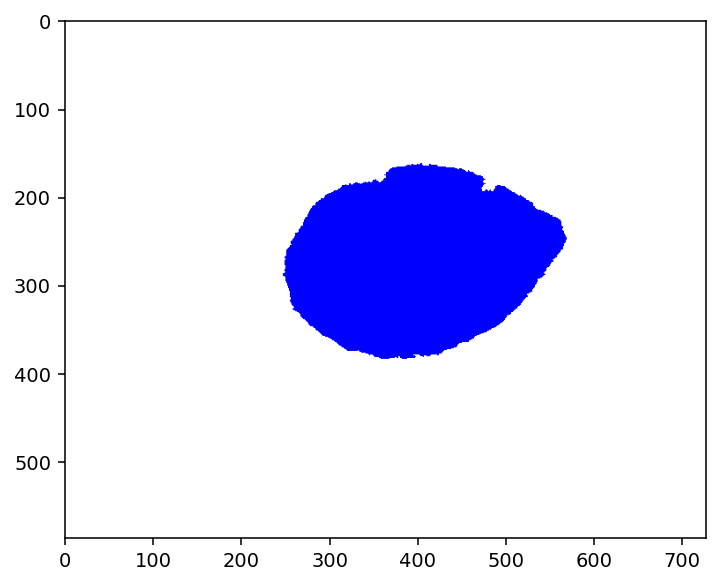

In [14]:
# Clean up the resulting mask with PlantCV
mask = results[0].masks.data.cpu().numpy()
mask = mask[0].astype(np.uint8)
filled = pcv.fill(mask, 200)
filled1 = pcv.fill_holes(filled)
inverted1 = pcv.invert(filled1)
colored_img = pcv.visualize.colorize_masks(masks=[filled1,inverted1], colors=['blue','white'])

# View the isolated seed wing

## to launch a Napari viewer with the overlay uncomment the code block below.
![overlay img](./img/overlay-points.png)

In [15]:
#Uncomment this code block if running this notebook locally or where a Napari viewer can be used.

#viewer3=pcvan.napari_open(img)
#viewer3.add_image(colored_img, opacity=0.5)


## Get seed size, shape, and color characteristics with PlantCV

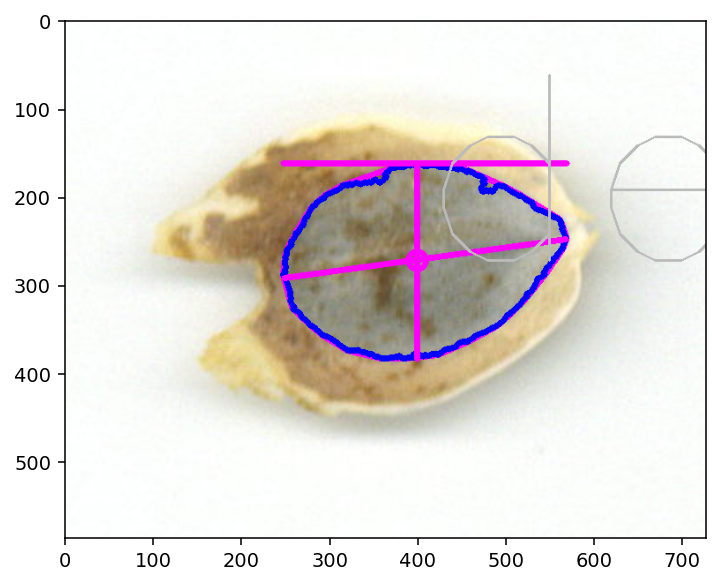

alt.FacetChart(...)

In [16]:
shape_image = pcv.analyze.size(img=img, labeled_mask=filled1, n_labels=1)
analysis_image = pcv.analyze.color(rgb_img=img, labeled_mask=filled1, n_labels=1, colorspaces='hsv')
